In [1]:
import zarr
import s3fs
import numpy as np

S3_BUCKET = "simulations"
STORE_PATH = "flow_export/A1/data.zarr"

fs = s3fs.S3FileSystem(profile='default', client_kwargs={
        'endpoint_url': 'http://localhost:9000'
    })

s3_map = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}", s3=fs)
z = zarr.open(
    store=s3_map,
    mode="r",
)

In [2]:
z.shape

(1694, 5, 128, 129, 128)

In [6]:
data = z[:20]

In [7]:
data.shape

(20, 5, 128, 129, 128)

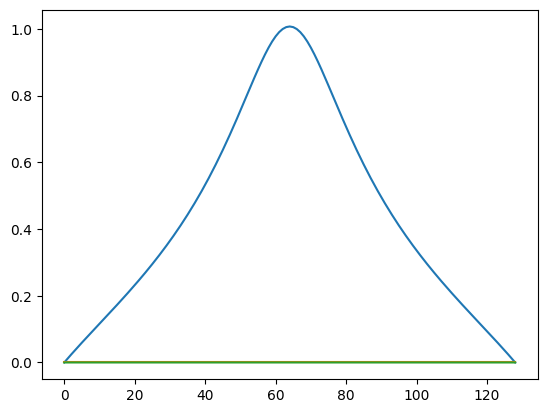

In [8]:
import matplotlib.pyplot as plt

plt.plot(data[:, 0].mean((0, 1, 3)))
plt.plot(data[:, 1].mean((0, 1, 3)))
plt.plot(data[:, 2].mean((0, 1, 3)))
plt.show()

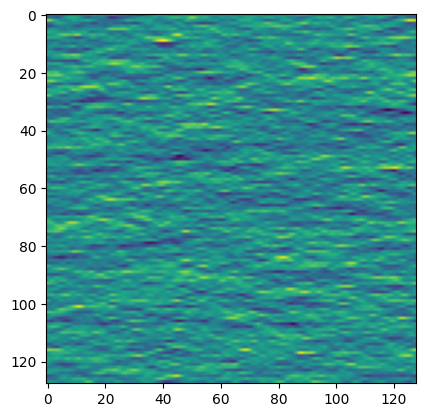

In [13]:
plt.imshow(data[0, 3, :, 50, :])
plt.show()